**SPDX-License-Identifier:** MIT  
**Copyright (C) 2026 Jinghui Zhong**  
*Companion source code for Chapter 2 of the book "Genetic Programming Algorithms and Applications" (《遗传编程算法及其应用》).*

# SGP 笔记本 1: 基础用法与可视化

本 notebook 演示 SGP (Standard Genetic Programming) 符号回归的基本用法，包含完整的实验风格可视化。

In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sgp import SGP

os.makedirs('figures', exist_ok=True)

plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'figure.dpi': 120,
    'savefig.dpi': 150,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
print('环境就绪')

环境就绪


## 实验 1: 发现 $y = x^2$

目标函数：$y = x^2$，定义域 $[-3, 3]$，100 个采样点。

In [12]:
np.random.seed(42)
X1 = np.linspace(-3, 3, 100).reshape(-1, 1)
y1 = (X1 ** 2).flatten()

model1 = SGP(seed=42, verbose=False)
model1.fit(X1, y1)

y_pred1 = model1.predict(X1)
r2_1 = r2_score(y1, y_pred1)

print(f'发现表达式: {model1.best_expression_}')
print(f'复杂度: {model1.best_complexity_} 节点')
print(f'进化代数: {model1.n_generations_}')
print(f'R²: {r2_1:.6f}')

发现表达式: mul(x0, x0)
复杂度: 3 节点
进化代数: 20
R²: 1.000000


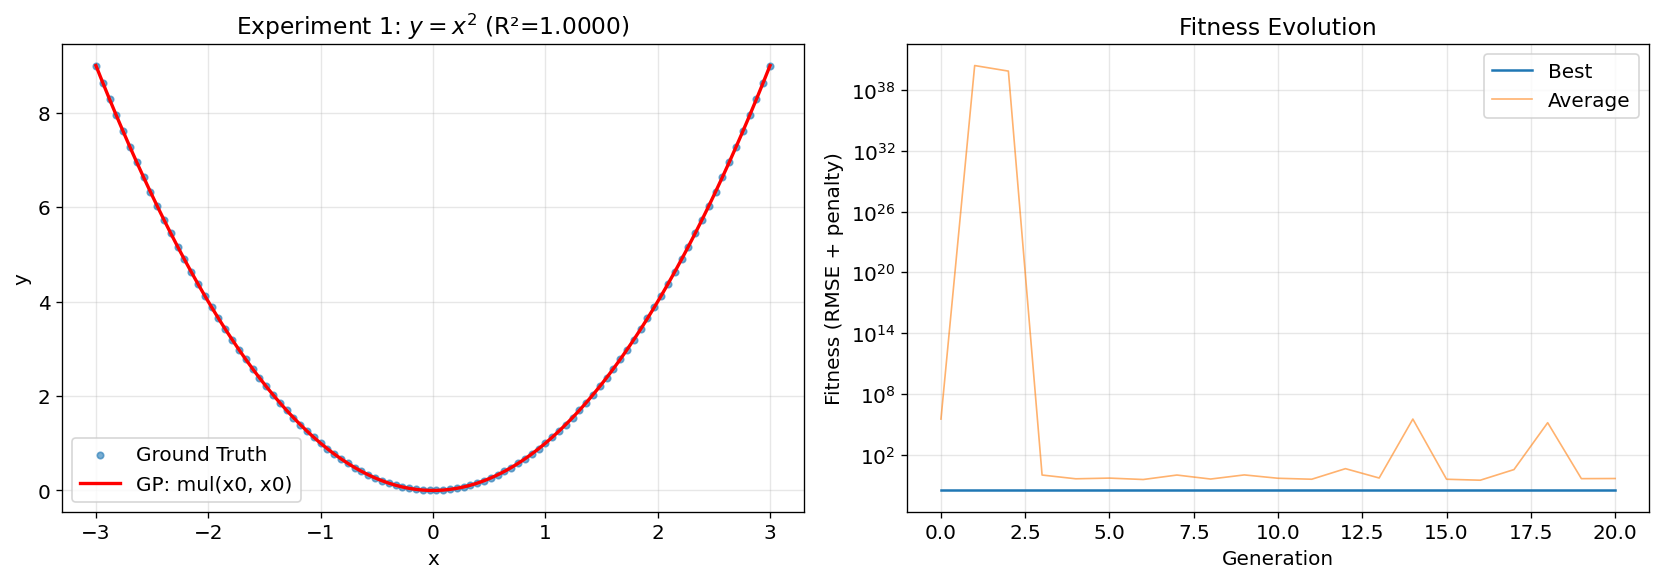

In [13]:
# 可视化: 拟合对比 + Fitness 曲线
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图: 拟合对比
ax = axes[0]
ax.scatter(X1.flatten(), y1, s=15, alpha=0.6, label='Ground Truth', zorder=3)
ax.plot(X1.flatten(), y_pred1, 'r-', linewidth=2, label=f'GP: {model1.best_expression_}', zorder=4)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(f'Experiment 1: $y = x^2$ (R²={r2_1:.4f})')
ax.legend()

# 右图: Fitness 进化
ax = axes[1]
gens = range(len(model1.history_["min"]))
ax.semilogy(gens, model1.history_["min"], linewidth=1.5, label='Best')
ax.semilogy(gens, model1.history_["avg"], linewidth=1, alpha=0.6, label='Average')
ax.set_xlabel('Generation')
ax.set_ylabel('Fitness (RMSE + penalty)')
ax.set_title('Fitness Evolution')
ax.legend()

fig.tight_layout()
fig.savefig('figures/exp1_x_squared.svg', bbox_inches='tight')
plt.show()

## 实验 2: 发现 $y = x_0 + x_1$

目标函数：$y = x_0 + x_1$，双变量，均匀随机采样。

In [14]:
np.random.seed(42)
X2 = np.random.uniform(-2, 2, (150, 2))
y2 = X2[:, 0] + X2[:, 1]

model2 = SGP(seed=42, verbose=False)
model2.fit(X2, y2)

y_pred2 = model2.predict(X2)
r2_2 = r2_score(y2, y_pred2)

print(f'发现表达式: {model2.best_expression_}')
print(f'R²: {r2_2:.6f}')

发现表达式: add(x0, x1)
R²: 1.000000


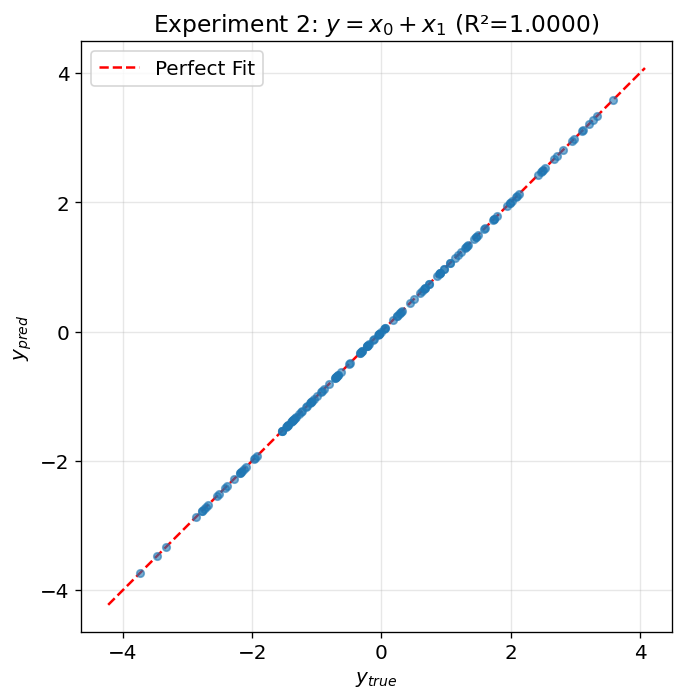

In [15]:
# 可视化: 双变量拟合 (y_true vs y_pred 散点图)
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y2, y_pred2, s=20, alpha=0.6, zorder=3)
lims = [min(y2.min(), y_pred2.min()) - 0.5, max(y2.max(), y_pred2.max()) + 0.5]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect Fit')
ax.set_xlabel('$y_{true}$')
ax.set_ylabel('$y_{pred}$')
ax.set_title(f'Experiment 2: $y = x_0 + x_1$ (R²={r2_2:.4f})')
ax.set_aspect('equal')
ax.legend()

fig.tight_layout()
fig.savefig('figures/exp2_addition.svg', bbox_inches='tight')
plt.show()

## 实验 3: 复杂函数 + 训练/测试分割

目标函数：$y = x^3 - 2x^2 + x$，含噪声。

In [16]:
np.random.seed(42)
X3 = np.linspace(-2, 2, 300).reshape(-1, 1)
y3 = (X3 ** 3 - 2 * X3 ** 2 + X3).flatten() + 0.5 * np.random.randn(300)

X_train, X_test, y_train, y_test = train_test_split(X3, y3, test_size=0.2, random_state=42)

model3 = SGP(pop_size=500, generations=80, seed=42, verbose=False)
model3.fit(X_train, y_train)

train_r2 = model3.score(X_train, y_train)
y_pred_test = model3.predict(X_test)
test_r2 = r2_score(y_test, y_pred_test)

print(f'发现表达式: {model3.best_expression_}')
print(f'复杂度: {model3.best_complexity_} 节点')
print(f'训练 R²: {train_r2:.4f}')
print(f'测试 R²: {test_r2:.4f}')

发现表达式: mul(mul(add(-0.9521794880479912, x0), x0), add(-0.9521794880479912, add(log(0.8960508742744271), x0)))
复杂度: 12 节点
训练 R²: 0.9891
测试 R²: 0.9927


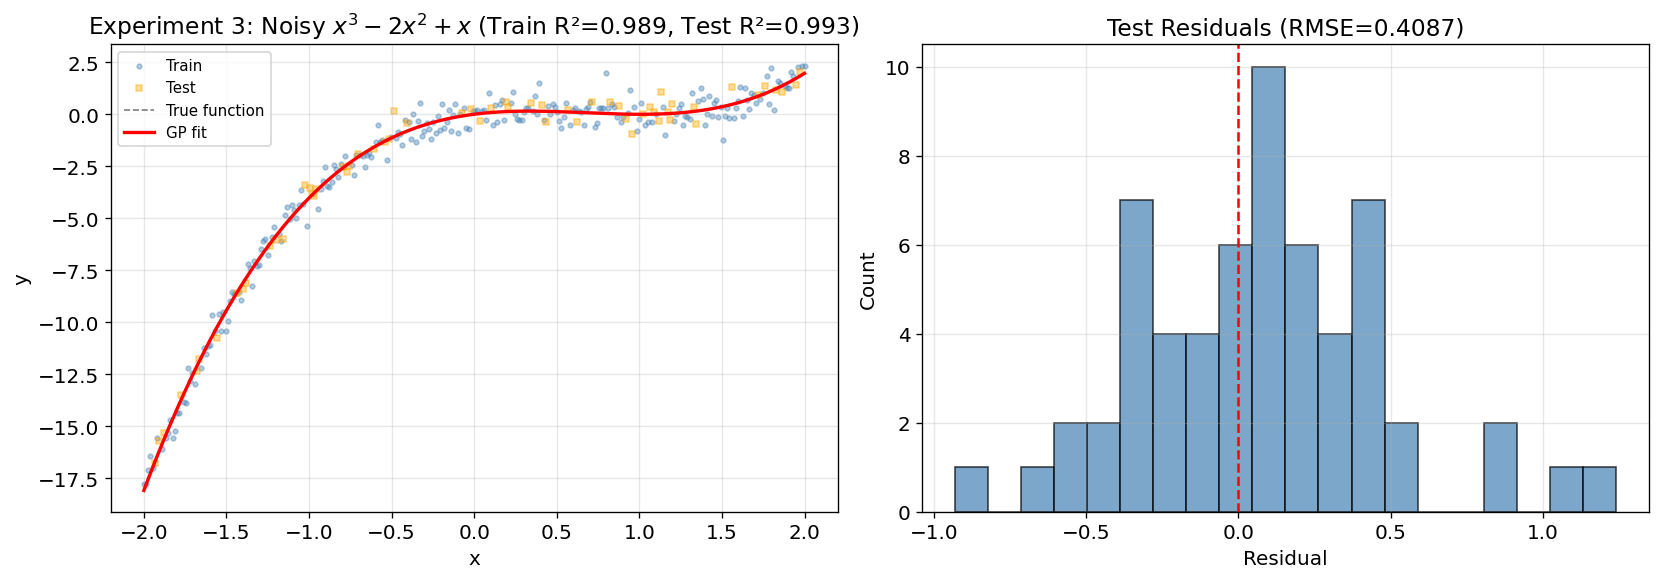

In [17]:
# 可视化: 带噪声数据的拟合效果
X_plot = np.linspace(-2, 2, 500).reshape(-1, 1)
y_true_plot = (X_plot ** 3 - 2 * X_plot ** 2 + X_plot).flatten()
y_pred_plot = model3.predict(X_plot)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图: 拟合对比
ax = axes[0]
ax.scatter(X_train.flatten(), y_train, s=8, alpha=0.4, c='steelblue', label='Train')
ax.scatter(X_test.flatten(), y_test, s=12, alpha=0.4, c='orange', marker='s', label='Test')
ax.plot(X_plot.flatten(), y_true_plot, 'k--', linewidth=1, alpha=0.5, label='True function')
ax.plot(X_plot.flatten(), y_pred_plot, 'r-', linewidth=2, label='GP fit')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(f'Experiment 3: Noisy $x^3-2x^2+x$ (Train R²={train_r2:.3f}, Test R²={test_r2:.3f})')
ax.legend(fontsize=9)

# 右图: 残差分布
ax = axes[1]
residuals = y_test - y_pred_test
ax.hist(residuals, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('Residual')
ax.set_ylabel('Count')
ax.set_title(f'Test Residuals (RMSE={np.sqrt(mean_squared_error(y_test, y_pred_test)):.4f})')

fig.tight_layout()
fig.savefig('figures/exp3_noisy_polynomial.svg', bbox_inches='tight')
plt.show()

## 实验 4: 三角函数发现

目标函数：$y = \sin(x) + \cos(2x)$。

In [18]:
np.random.seed(42)
X4 = np.linspace(0, 2 * np.pi, 200).reshape(-1, 1)
y4 = (np.sin(X4) + np.cos(2 * X4)).flatten()

model4 = SGP(pop_size=500, generations=100, seed=42, verbose=False)
model4.fit(X4, y4)

y_pred4 = model4.predict(X4)
r2_4 = r2_score(y4, y_pred4)

print(f'发现表达式: {model4.best_expression_}')
print(f'R²: {r2_4:.6f}')

发现表达式: sin(x0)
R²: 0.497487


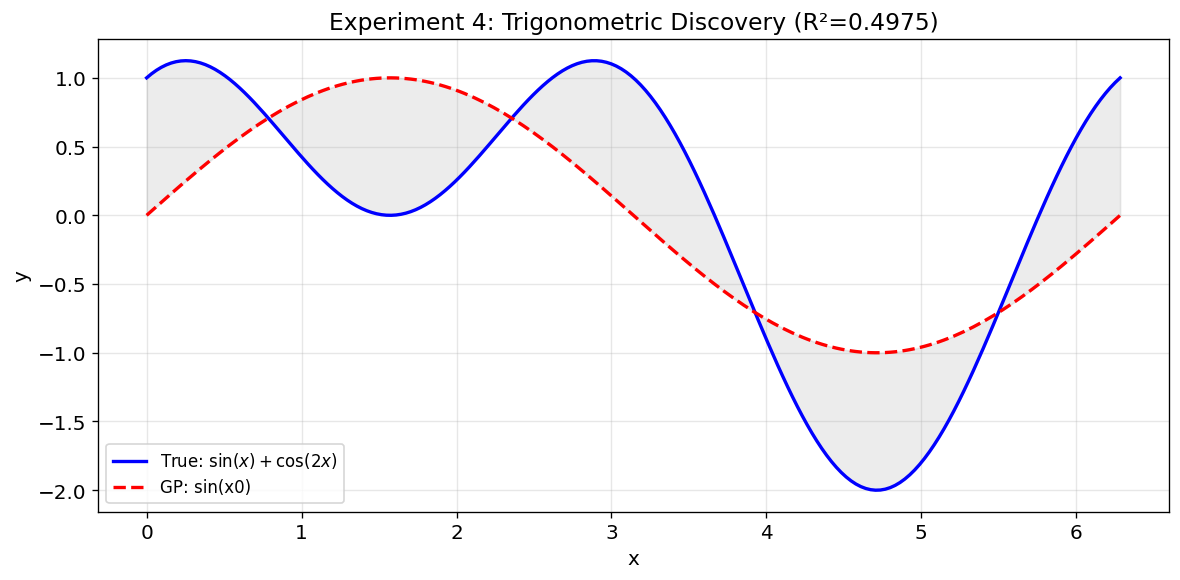

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(X4.flatten(), y4, 'b-', linewidth=2, label='True: $\\sin(x) + \\cos(2x)$')
ax.plot(X4.flatten(), y_pred4, 'r--', linewidth=2, label=f'GP: {model4.best_expression_}')
ax.fill_between(X4.flatten(), y4, y_pred4, alpha=0.15, color='gray')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(f'Experiment 4: Trigonometric Discovery (R²={r2_4:.4f})')
ax.legend(fontsize=10)

fig.tight_layout()
fig.savefig('figures/exp4_trigonometric.svg', bbox_inches='tight')
plt.show()

## 实验总结

In [20]:
results = [
    {'Experiment': '$y = x^2$', 'Expression': model1.best_expression_,
     'Complexity': model1.best_complexity_, 'R²': r2_1},
    {'Experiment': '$y = x_0 + x_1$', 'Expression': model2.best_expression_,
     'Complexity': model2.best_complexity_, 'R²': r2_2},
    {'Experiment': '$x^3-2x^2+x$+noise', 'Expression': model3.best_expression_,
     'Complexity': model3.best_complexity_, 'R²': test_r2},
    {'Experiment': '$\\sin(x)+\\cos(2x)$', 'Expression': model4.best_expression_,
     'Complexity': model4.best_complexity_, 'R²': r2_4},
]

print(f'{"Experiment":<25} {"Expression":<35} {"Nodes":>5} {"R²":>8}')
print('-' * 75)
for r in results:
    print(f'{r["Experiment"]:<25} {r["Expression"]:<35} {r["Complexity"]:>5} {r["R²"]:>8.4f}')

Experiment                Expression                          Nodes       R²
---------------------------------------------------------------------------
$y = x^2$                 mul(x0, x0)                             3   1.0000
$y = x_0 + x_1$           add(x0, x1)                             3   1.0000
$x^3-2x^2+x$+noise        mul(mul(add(-0.9521794880479912, x0), x0), add(-0.9521794880479912, add(log(0.8960508742744271), x0)))    12   0.9927
$\sin(x)+\cos(2x)$        sin(x0)                                 2   0.4975
